In [29]:
from sklearn.datasets import load_wine
import pandas as pd

# 使用Wine葡萄酒数据集，适用于更复杂的决策树实验
wine = load_wine(as_frame=True)
X = wine.data      # 特征 DataFrame
y = wine.target    # 标签 Series（0,1,2，对应三种葡萄酒）

# 可以将y转为字符串标签，便于可视化和分析
y = pd.Series(wine.target, name="wine_class").map(dict(enumerate(wine.target_names)))

print(X.head())
print(X.dtypes)
print(y.value_counts())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

In [30]:
import pandas as pd
import numpy as np

# 连续特征：数值型
continuous_features = X.select_dtypes(include=[np.number]).columns.tolist()
# 离散特征：非数值型
discrete_features = [c for c in X.columns if c not in continuous_features]

print("连续特征：", continuous_features)
print("离散特征：", discrete_features)

连续特征： ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
离散特征： []


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y, shuffle=True
)

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# 对离散特征做 One-Hot，连续特征原样传递
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), discrete_features),
        ("num", "passthrough", continuous_features),
    ]
)

X_train_sklearn = preprocess.fit_transform(X_train)
X_test_sklearn = preprocess.transform(X_test)

In [33]:
from decision_tree_ID3 import DecisionTreeContinuous as ID3Tree
from decision_tree_C45 import DecisionTreeC45
from decision_tree_CART import DecisionTreeCART
from sklearn.metrics import accuracy_score, classification_report

In [34]:
id3 = ID3Tree(
    min_samples_split=10,
    continuous_features=continuous_features  # 直接用上面识别好的连续特征名列表
)
id3.fit(X_train, y_train)

id3_train_pred = id3.predict(X_train)
id3_test_pred = id3.predict(X_test)

print("ID3 训练集准确率:", accuracy_score(y_train, id3_train_pred))
print("ID3 测试集准确率:", accuracy_score(y_test, id3_test_pred))

ID3 训练集准确率: 1.0
ID3 测试集准确率: 0.9074074074074074


In [35]:
c45 = DecisionTreeC45(
    min_samples_split=10,
    min_samples_leaf=5,
    max_depth=None,
    continuous_features=continuous_features
)
c45.fit(X_train, y_train)

c45_train_pred = c45.predict(X_train)
c45_test_pred = c45.predict(X_test)

print("C4.5 训练集准确率:", accuracy_score(y_train, c45_train_pred))
print("C4.5 测试集准确率:", accuracy_score(y_test, c45_test_pred))

C4.5 训练集准确率: 0.9838709677419355
C4.5 测试集准确率: 0.9444444444444444


In [8]:
cart = DecisionTreeCART(
    min_samples_split=10,
    min_samples_leaf=5,
    max_depth=None,
    continuous_features=continuous_features
)
cart.fit(X_train, y_train)

cart_train_pred = cart.predict(X_train)
cart_test_pred = cart.predict(X_test)

print("CART 训练集准确率:", accuracy_score(y_train, cart_train_pred))
print("CART 测试集准确率:", accuracy_score(y_test, cart_test_pred))

CART 训练集准确率: 0.967741935483871
CART 测试集准确率: 0.9629629629629629


In [9]:
from sklearn.tree import DecisionTreeClassifier

# Entropy（类似 ID3/C4.5）
dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)
dt_entropy.fit(X_train_sklearn, y_train)

# Gini（类似 CART）
dt_gini = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)
dt_gini.fit(X_train_sklearn, y_train)

# 评估
dt_entropy_train_pred = dt_entropy.predict(X_train_sklearn)
dt_entropy_test_pred = dt_entropy.predict(X_test_sklearn)

dt_gini_train_pred = dt_gini.predict(X_train_sklearn)
dt_gini_test_pred = dt_gini.predict(X_test_sklearn)

print("sklearn-Entropy 训练集准确率:", accuracy_score(y_train, dt_entropy_train_pred))
print("sklearn-Entropy 测试集准确率:", accuracy_score(y_test, dt_entropy_test_pred))

print("sklearn-Gini 训练集准确率:", accuracy_score(y_train, dt_gini_train_pred))
print("sklearn-Gini 测试集准确率:", accuracy_score(y_test, dt_gini_test_pred))

sklearn-Entropy 训练集准确率: 1.0
sklearn-Entropy 测试集准确率: 0.9074074074074074
sklearn-Gini 训练集准确率: 1.0
sklearn-Gini 测试集准确率: 0.9629629629629629


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "algorithm": ["ID3", "C4.5", "CART", "sklearn-Entropy", "sklearn-Gini"],
    "train_accuracy": [
        accuracy_score(y_train, id3_train_pred),
        accuracy_score(y_train, c45_train_pred),
        accuracy_score(y_train, cart_train_pred),
        accuracy_score(y_train, dt_entropy_train_pred),
        accuracy_score(y_train, dt_gini_train_pred),
    ],
    "test_accuracy": [
        accuracy_score(y_test, id3_test_pred),
        accuracy_score(y_test, c45_test_pred),
        accuracy_score(y_test, cart_test_pred),
        accuracy_score(y_test, dt_entropy_test_pred),
        accuracy_score(y_test, dt_gini_test_pred),
    ],
})

print(results)

         algorithm  train_accuracy  test_accuracy
0              ID3        1.000000       0.907407
1             C4.5        0.983871       0.944444
2             CART        0.967742       0.962963
3  sklearn-Entropy        1.000000       0.907407
4     sklearn-Gini        1.000000       0.962963


In [11]:
# 训练带后剪枝的模型
print("="*60)
print("训练后剪枝模型...")
print("="*60)

# ID3 with pruning
id3_pruned = ID3Tree(
    min_samples_split=10,
    continuous_features=continuous_features,
    prune=True,
    validation_split=0.2
)
id3_pruned.fit(X_train, y_train)
id3_pruned_train_pred = id3_pruned.predict(X_train)
id3_pruned_test_pred = id3_pruned.predict(X_test)

print(f"ID3 (剪枝) 训练集准确率: {accuracy_score(y_train, id3_pruned_train_pred):.6f}")
print(f"ID3 (剪枝) 测试集准确率: {accuracy_score(y_test, id3_pruned_test_pred):.6f}")

# C4.5 with pruning
c45_pruned = DecisionTreeC45(
    min_samples_split=10,
    min_samples_leaf=5,
    max_depth=None,
    continuous_features=continuous_features,
    prune=True,
    validation_split=0.2
)
c45_pruned.fit(X_train, y_train)
c45_pruned_train_pred = c45_pruned.predict(X_train)
c45_pruned_test_pred = c45_pruned.predict(X_test)

print(f"C4.5 (剪枝) 训练集准确率: {accuracy_score(y_train, c45_pruned_train_pred):.6f}")
print(f"C4.5 (剪枝) 测试集准确率: {accuracy_score(y_test, c45_pruned_test_pred):.6f}")

# CART with pruning
cart_pruned = DecisionTreeCART(
    min_samples_split=10,
    min_samples_leaf=5,
    max_depth=None,
    continuous_features=continuous_features,
    prune=True,
    validation_split=0.2
)
cart_pruned.fit(X_train, y_train)
cart_pruned_train_pred = cart_pruned.predict(X_train)
cart_pruned_test_pred = cart_pruned.predict(X_test)

print(f"CART (剪枝) 训练集准确率: {accuracy_score(y_train, cart_pruned_train_pred):.6f}")
print(f"CART (剪枝) 测试集准确率: {accuracy_score(y_test, cart_pruned_test_pred):.6f}")


训练后剪枝模型...
ID3 (剪枝) 训练集准确率: 0.967742
ID3 (剪枝) 测试集准确率: 0.907407
C4.5 (剪枝) 训练集准确率: 0.911290
C4.5 (剪枝) 测试集准确率: 0.870370
CART (剪枝) 训练集准确率: 0.951613
CART (剪枝) 测试集准确率: 0.962963


In [12]:
# 汇总所有模型结果（包括剪枝前后对比）
all_results = pd.DataFrame({
    "algorithm": [
        "ID3 (raw)", "ID3 (pruning)", 
        "C4.5 (raw)", "C4.5 (pruning)",
        "CART (raw)", "CART (pruning)",
        "sklearn-Entropy", "sklearn-Gini"
    ],
    "train_accuracy": [
        accuracy_score(y_train, id3_train_pred),
        accuracy_score(y_train, id3_pruned_train_pred),
        accuracy_score(y_train, c45_train_pred),
        accuracy_score(y_train, c45_pruned_train_pred),
        accuracy_score(y_train, cart_train_pred),
        accuracy_score(y_train, cart_pruned_train_pred),
        accuracy_score(y_train, dt_entropy_train_pred),
        accuracy_score(y_train, dt_gini_train_pred),
    ],
    "test_accuracy": [
        accuracy_score(y_test, id3_test_pred),
        accuracy_score(y_test, id3_pruned_test_pred),
        accuracy_score(y_test, c45_test_pred),
        accuracy_score(y_test, c45_pruned_test_pred),
        accuracy_score(y_test, cart_test_pred),
        accuracy_score(y_test, cart_pruned_test_pred),
        accuracy_score(y_test, dt_entropy_test_pred),
        accuracy_score(y_test, dt_gini_test_pred),
    ],
})

# 计算过拟合程度
all_results["overfitting"] = all_results["train_accuracy"] - all_results["test_accuracy"]

print("="*80)
print("所有模型性能对比（包括剪枝前后）")
print("="*80)
print(all_results.to_string(index=False))
print("="*80)


所有模型性能对比（包括剪枝前后）
      algorithm  train_accuracy  test_accuracy  overfitting
      ID3 (raw)        1.000000       0.907407     0.092593
  ID3 (pruning)        0.967742       0.907407     0.060335
     C4.5 (raw)        0.983871       0.944444     0.039427
 C4.5 (pruning)        0.911290       0.870370     0.040920
     CART (raw)        0.967742       0.962963     0.004779
 CART (pruning)        0.951613       0.962963    -0.011350
sklearn-Entropy        1.000000       0.907407     0.092593
   sklearn-Gini        1.000000       0.962963     0.037037


 图片已保存: pic/wine_accuracy_comparison.png


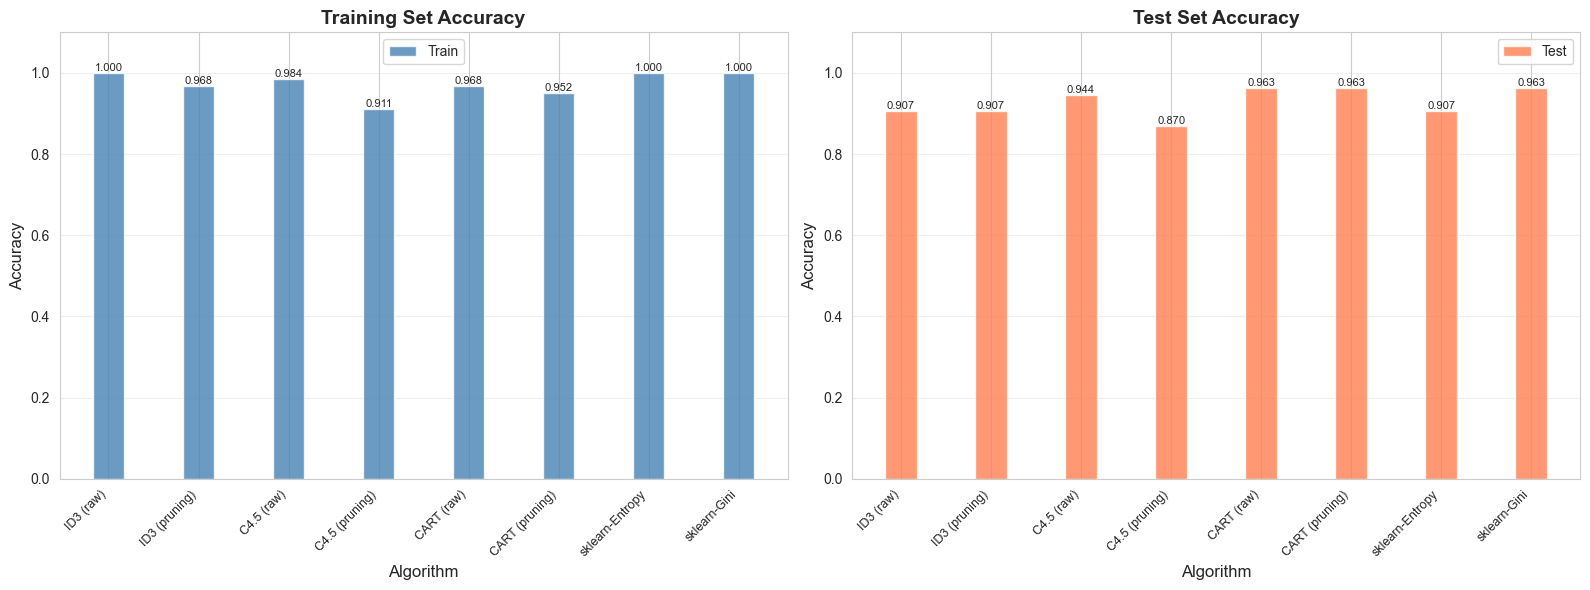

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

pic_dir = 'pic'

# 准确率对比图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 训练集准确率
ax1 = axes[0]
x = np.arange(len(all_results))
width = 0.35

bars1 = ax1.bar(x, all_results['train_accuracy'], width, label='Train', 
                color='steelblue', alpha=0.8)
ax1.set_xlabel('Algorithm', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Training Set Accuracy', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(all_results['algorithm'], rotation=45, ha='right', fontsize=9)
ax1.set_ylim([0, 1.1])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 添加数值标签
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom', fontsize=8)

# 测试集准确率
ax2 = axes[1]
bars2 = ax2.bar(x, all_results['test_accuracy'], width, label='Test',
                color='coral', alpha=0.8)
ax2.set_xlabel('Algorithm', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Test Set Accuracy', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(all_results['algorithm'], rotation=45, ha='right', fontsize=9)
ax2.set_ylim([0, 1.1])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 添加数值标签
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{pic_dir}/wine_accuracy_comparison.png', dpi=300, bbox_inches='tight')
print(f" 图片已保存: {pic_dir}/wine_accuracy_comparison.png")
plt.show()


✓ 图片已保存: pic/wine_train_test_comparison.png


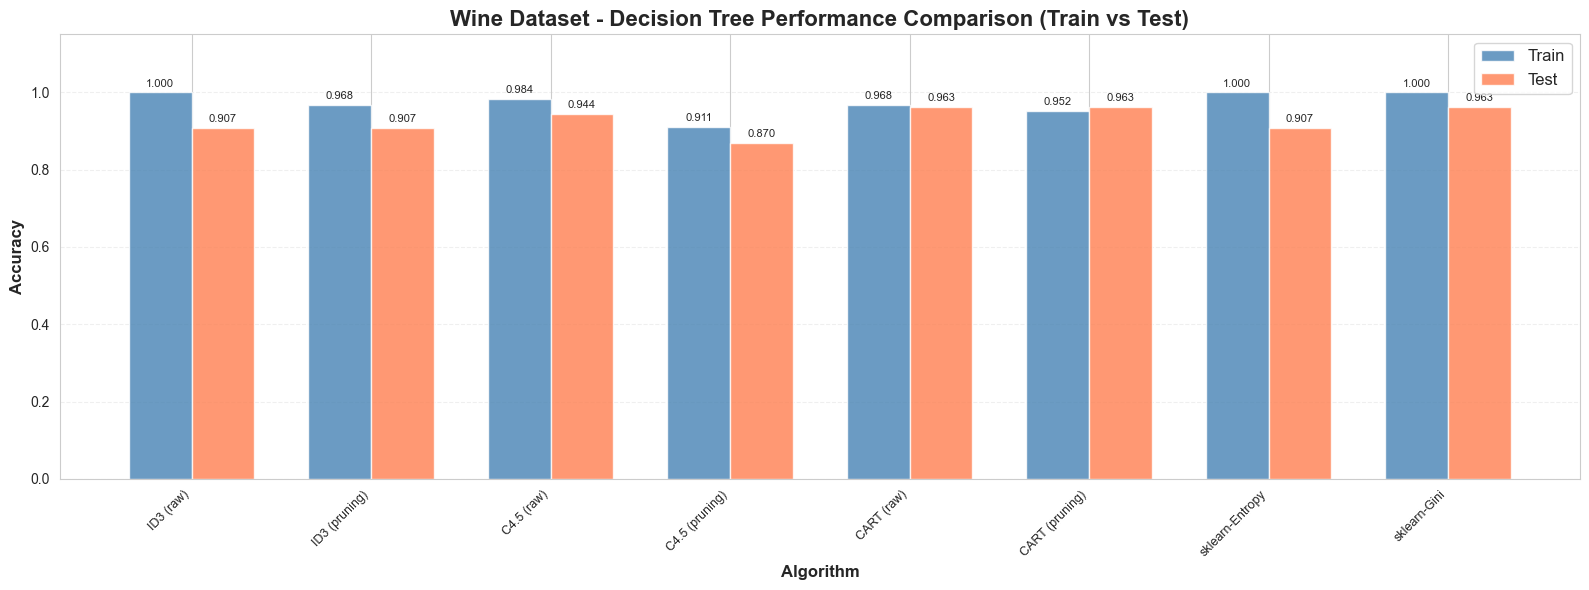

In [16]:
# 训练集vs测试集准确率对比（并排）
fig, ax = plt.subplots(figsize=(16, 6))

x = np.arange(len(all_results))
width = 0.35

bars1 = ax.bar(x - width/2, all_results['train_accuracy'], width, 
               label='Train', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, all_results['test_accuracy'], width,
               label='Test', color='coral', alpha=0.8)

ax.set_xlabel('Algorithm', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Wine Dataset - Decision Tree Performance Comparison (Train vs Test)', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(all_results['algorithm'], rotation=45, ha='right', fontsize=9)
ax.set_ylim([0, 1.15])
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# 添加数值标签
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{pic_dir}/wine_train_test_comparison.png', dpi=300, bbox_inches='tight')
print(f"✓ 图片已保存: {pic_dir}/wine_train_test_comparison.png")
plt.show()


✓ Image saved: pic/wine_confusion_matrix.png


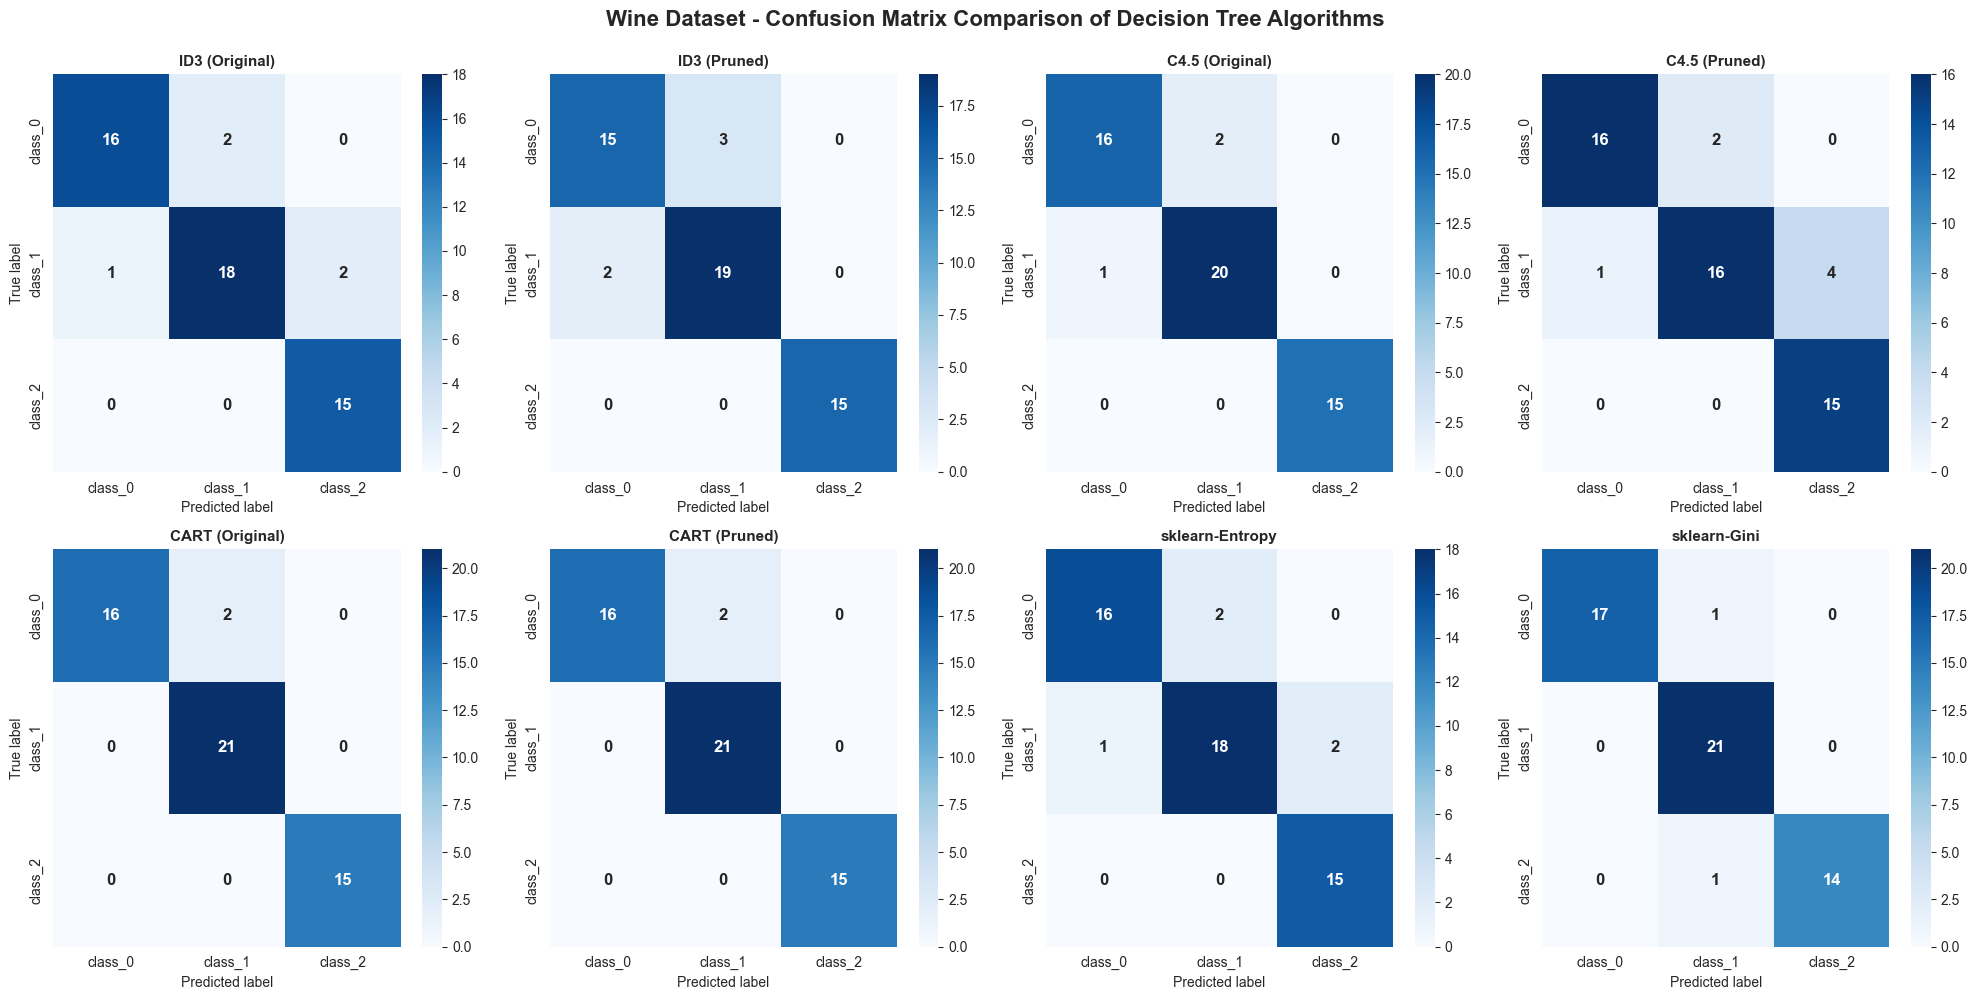

In [17]:
from sklearn.metrics import confusion_matrix

# Prepare predictions for all models
models_predictions = [
    ('ID3 (Original)', id3_test_pred),
    ('ID3 (Pruned)', id3_pruned_test_pred),
    ('C4.5 (Original)', c45_test_pred),
    ('C4.5 (Pruned)', c45_pruned_test_pred),
    ('CART (Original)', cart_test_pred),
    ('CART (Pruned)', cart_pruned_test_pred),
    ('sklearn-Entropy', dt_entropy_test_pred),
    ('sklearn-Gini', dt_gini_test_pred)
]

# Use actual class names/labels from the wine dataset
wine_labels = sorted(y_test.unique().tolist())

# Create confusion matrix plots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (name, pred) in enumerate(models_predictions):
    cm = confusion_matrix(y_test, pred, labels=wine_labels)
    
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', 
        xticklabels=wine_labels, 
        yticklabels=wine_labels,
        ax=axes[i], cbar=True,
        annot_kws={'size': 12, 'weight': 'bold'}
    )
    
    axes[i].set_title(name, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted label', fontsize=10)
    axes[i].set_ylabel('True label', fontsize=10)

plt.suptitle('Wine Dataset - Confusion Matrix Comparison of Decision Tree Algorithms',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f'{pic_dir}/wine_confusion_matrix.png', dpi=300, bbox_inches='tight')
print(f"✓ Image saved: {pic_dir}/wine_confusion_matrix.png")
plt.show()


In [18]:
# 获取各算法的特征重要性
id3_importance = id3.get_feature_importances()
id3_pruned_importance = id3_pruned.get_feature_importances()
c45_importance = c45.get_feature_importances()
c45_pruned_importance = c45_pruned.get_feature_importances()
cart_importance = cart.get_feature_importances()
cart_pruned_importance = cart_pruned.get_feature_importances()

# sklearn的特征重要性
sklearn_entropy_importance = dict(zip(X_train.columns, dt_entropy.feature_importances_))
sklearn_gini_importance = dict(zip(X_train.columns, dt_gini.feature_importances_))

print("="*60)
print("特征重要性对比")
print("="*60)

# 创建特征重要性对比表
all_features = X_train.columns.tolist()
importance_df = pd.DataFrame({
    '特征': all_features,
    'ID3 (原始)': [id3_importance.get(f, 0.0) for f in all_features],
    'ID3 (剪枝)': [id3_pruned_importance.get(f, 0.0) for f in all_features],
    'C4.5 (原始)': [c45_importance.get(f, 0.0) for f in all_features],
    'C4.5 (剪枝)': [c45_pruned_importance.get(f, 0.0) for f in all_features],
    'CART (原始)': [cart_importance.get(f, 0.0) for f in all_features],
    'CART (剪枝)': [cart_pruned_importance.get(f, 0.0) for f in all_features],
    'sklearn-Entropy': [sklearn_entropy_importance.get(f, 0.0) for f in all_features],
    'sklearn-Gini': [sklearn_gini_importance.get(f, 0.0) for f in all_features]
})

# 按重要性排序（取前10个最重要的特征）
importance_df_sorted = importance_df.sort_values(by='ID3 (原始)', ascending=False)
print("\n前10个最重要的特征（按ID3原始模型）:")
print(importance_df_sorted.head(10).to_string(index=False))


特征重要性对比

前10个最重要的特征（按ID3原始模型）:
                  特征  ID3 (原始)  ID3 (剪枝)  C4.5 (原始)  C4.5 (剪枝)  CART (原始)  CART (剪枝)  sklearn-Entropy  sklearn-Gini
          flavanoids  0.409101  0.398259   0.386895   0.000000   0.435446   0.439533         0.409101      0.404915
             alcohol  0.342015  0.167485   0.281752   0.445546   0.018766   0.022774         0.342015      0.000000
                 hue  0.148506  0.000000   0.000000   0.000000   0.000000   0.000000         0.148506      0.000000
           magnesium  0.100379  0.000000   0.143087   0.106146   0.000000   0.000000         0.000000      0.000000
          malic_acid  0.000000  0.000000   0.021844   0.000000   0.004502   0.000000         0.000000      0.021034
   alcalinity_of_ash  0.000000  0.000000   0.000000   0.000000   0.000000   0.000000         0.000000      0.023818
                 ash  0.000000  0.000000   0.000000   0.000000   0.000000   0.000000         0.000000      0.022916
nonflavanoid_phenols  0.000000  0.000000 

✓ 图片已保存: pic/wine_feature_importance.png


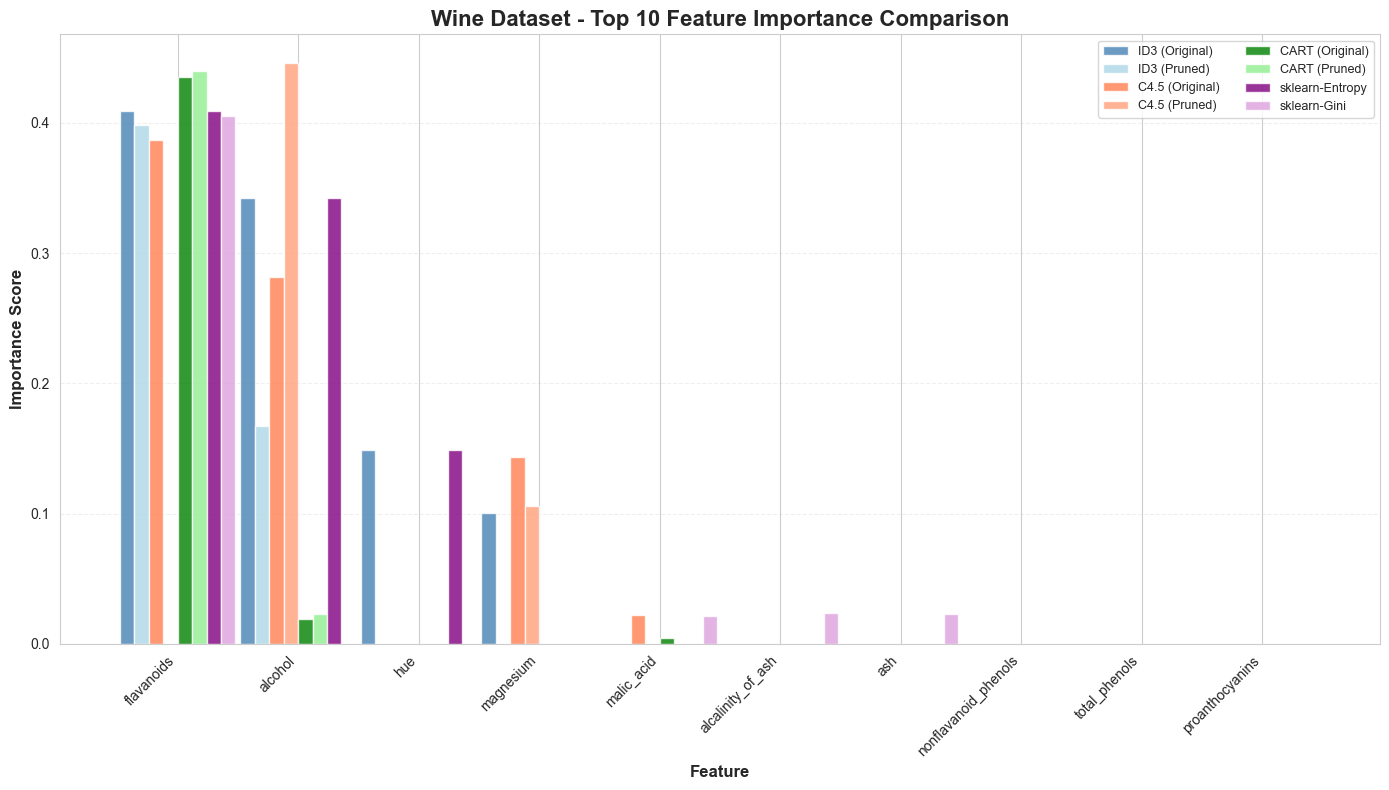

In [19]:
# 特征重要性可视化（前10个特征）
top_n = 10
top_features = importance_df_sorted.head(top_n)['特征'].tolist()
top_importance_df = importance_df_sorted.head(top_n)

fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(top_features))
width = 0.12

# English algorithm names for plotting
algorithms_en = ['ID3 (Original)', 'ID3 (Pruned)', 'C4.5 (Original)', 'C4.5 (Pruned)',
                 'CART (Original)', 'CART (Pruned)', 'sklearn-Entropy', 'sklearn-Gini']
algorithm_column_mapping_en = {
    'ID3 (Original)':      'ID3 (原始)',
    'ID3 (Pruned)':        'ID3 (剪枝)',
    'C4.5 (Original)':     'C4.5 (原始)',
    'C4.5 (Pruned)':       'C4.5 (剪枝)',
    'CART (Original)':     'CART (原始)',
    'CART (Pruned)':       'CART (剪枝)',
    'sklearn-Entropy':     'sklearn-Entropy',
    'sklearn-Gini':        'sklearn-Gini'
}
colors = ['steelblue', 'lightblue', 'coral', 'lightsalmon',
          'green', 'lightgreen', 'purple', 'plum']

for i, (algo_en, color) in enumerate(zip(algorithms_en, colors)):
    offset = (i - len(algorithms_en)/2) * width + width/2
    bars = ax.bar(x + offset, top_importance_df[algorithm_column_mapping_en[algo_en]], width, 
                  label=algo_en, color=color, alpha=0.8)

ax.set_xlabel('Feature', fontsize=12, fontweight='bold')
ax.set_ylabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title(f'Wine Dataset - Top {top_n} Feature Importance Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top_features, rotation=45, ha='right')
ax.legend(fontsize=9, ncol=2)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(f'{pic_dir}/wine_feature_importance.png', dpi=300, bbox_inches='tight')
print(f"✓ 图片已保存: {pic_dir}/wine_feature_importance.png")
plt.show()


C:\Users\SJQ\AppData\Roaming\Python\Python39\site-packages\seaborn\utils.py:61: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\SJQ\AppData\Roaming\Python\Python39\site-packages\seaborn\utils.py:61: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\SJQ\AppData\Roaming\Python\Python39\site-packages\seaborn\utils.py:61: UserWarning: Glyph 21098 (\N{CJK UNIFIED IDEOGRAPH-526A}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\SJQ\AppData\Roaming\Python\Python39\site-packages\seaborn\utils.py:61: UserWarning: Glyph 26525 (\N{CJK UNIFIED IDEOGRAPH-679D}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\SJQ\AppData\Local\Temp\ipykernel_53088\1897300414.py:16: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) Arial.
  plt.savefig(f'{pic_dir}/wine_feature_importance_heatmap.png', dpi=300, bbox_inches='tight')
C:\Users\S

✓ Image saved: pic/wine_feature_importance_heatmap.png


d:\miniconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\miniconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\miniconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21098 (\N{CJK UNIFIED IDEOGRAPH-526A}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\miniconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26525 (\N{CJK UNIFIED IDEOGRAPH-679D}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


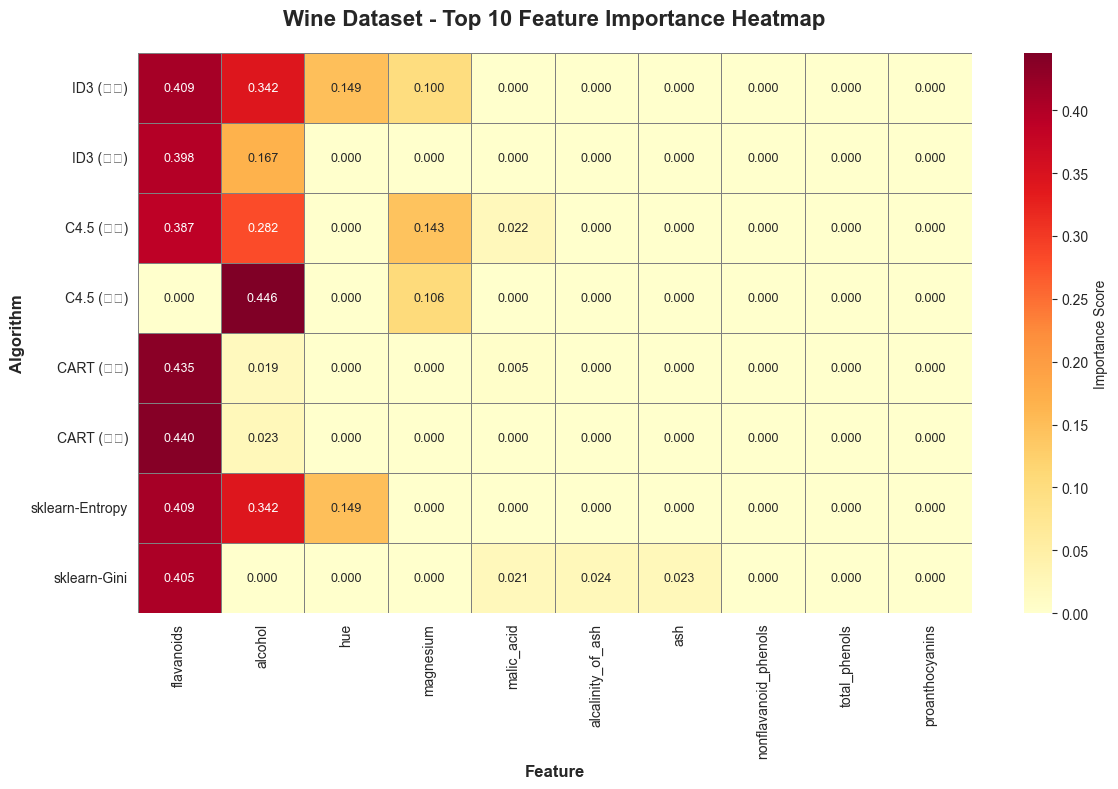

In [21]:
# 特征重要性热力图（前10个特征）
fig, ax = plt.subplots(figsize=(12, 8))

heatmap_data = top_importance_df.set_index('特征').T

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', 
            cbar_kws={'label': 'Importance Score'}, ax=ax, 
            linewidths=0.5, linecolor='gray',
            annot_kws={'size': 9})

ax.set_title(f'Wine Dataset - Top {top_n} Feature Importance Heatmap', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Feature', fontsize=12, fontweight='bold')
ax.set_ylabel('Algorithm', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{pic_dir}/wine_feature_importance_heatmap.png', dpi=300, bbox_inches='tight')
print(f"✓ Image saved: {pic_dir}/wine_feature_importance_heatmap.png")
plt.show()


✓ Image saved: pic/wine_overfitting_analysis.png


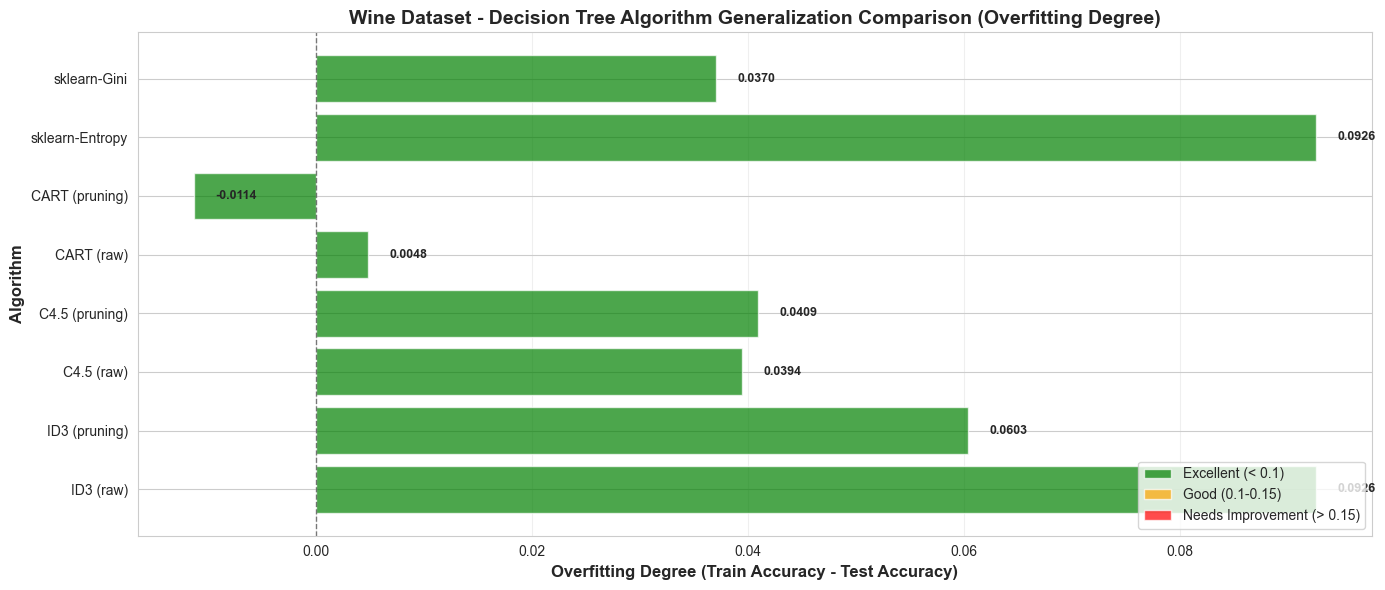

In [24]:
# 过拟合程度可视化
fig, ax = plt.subplots(figsize=(14, 6))

# 保证用于图像的数据和标签同步（全部用 all_results）
bar_labels = all_results['algorithm']
overfit_values = all_results['overfitting']

colors = ['green' if x < 0.1 else 'orange' if x < 0.15 else 'red' 
          for x in overfit_values]

bars = ax.barh(bar_labels, overfit_values, color=colors, alpha=0.7)
ax.set_xlabel('Overfitting Degree (Train Accuracy - Test Accuracy)', fontsize=12, fontweight='bold')
ax.set_ylabel('Algorithm', fontsize=12, fontweight='bold')
ax.set_title('Wine Dataset - Decision Tree Algorithm Generalization Comparison (Overfitting Degree)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(axis='x', alpha=0.3)

# 添加数值标签（同步 all_results 数据）
for bar, val in zip(bars, overfit_values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}',
            va='center', fontsize=9, fontweight='bold')

# 添加图例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.7, label='Excellent (< 0.1)'),
    Patch(facecolor='orange', alpha=0.7, label='Good (0.1-0.15)'),
    Patch(facecolor='red', alpha=0.7, label='Needs Improvement (> 0.15)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(f'{pic_dir}/wine_overfitting_analysis.png', dpi=300, bbox_inches='tight')
print(f"✓ Image saved: {pic_dir}/wine_overfitting_analysis.png")
plt.show()


In [25]:
# 剪枝前后对比
pruning_comparison = pd.DataFrame({
    '算法': ['ID3', 'C4.5', 'CART'],
    '原始-训练集准确率': [
        accuracy_score(y_train, id3_train_pred),
        accuracy_score(y_train, c45_train_pred),
        accuracy_score(y_train, cart_train_pred)
    ],
    '剪枝-训练集准确率': [
        accuracy_score(y_train, id3_pruned_train_pred),
        accuracy_score(y_train, c45_pruned_train_pred),
        accuracy_score(y_train, cart_pruned_train_pred)
    ],
    '原始-测试集准确率': [
        accuracy_score(y_test, id3_test_pred),
        accuracy_score(y_test, c45_test_pred),
        accuracy_score(y_test, cart_test_pred)
    ],
    '剪枝-测试集准确率': [
        accuracy_score(y_test, id3_pruned_test_pred),
        accuracy_score(y_test, c45_pruned_test_pred),
        accuracy_score(y_test, cart_pruned_test_pred)
    ],
    '原始-过拟合程度': [
        accuracy_score(y_train, id3_train_pred) - accuracy_score(y_test, id3_test_pred),
        accuracy_score(y_train, c45_train_pred) - accuracy_score(y_test, c45_test_pred),
        accuracy_score(y_train, cart_train_pred) - accuracy_score(y_test, cart_test_pred)
    ],
    '剪枝-过拟合程度': [
        accuracy_score(y_train, id3_pruned_train_pred) - accuracy_score(y_test, id3_pruned_test_pred),
        accuracy_score(y_train, c45_pruned_train_pred) - accuracy_score(y_test, c45_pruned_test_pred),
        accuracy_score(y_train, cart_pruned_train_pred) - accuracy_score(y_test, cart_pruned_test_pred)
    ],
})

# 计算改进
pruning_comparison['测试集准确率提升'] = (
    pruning_comparison['剪枝-测试集准确率'] - pruning_comparison['原始-测试集准确率']
)
pruning_comparison['过拟合减少'] = (
    pruning_comparison['原始-过拟合程度'] - pruning_comparison['剪枝-过拟合程度']
)

print("="*80)
print("后剪枝效果对比分析")
print("="*80)
print(pruning_comparison.to_string(index=False))
print("="*80)


后剪枝效果对比分析
  算法  原始-训练集准确率  剪枝-训练集准确率  原始-测试集准确率  剪枝-测试集准确率  原始-过拟合程度  剪枝-过拟合程度  测试集准确率提升     过拟合减少
 ID3   1.000000   0.967742   0.907407   0.907407  0.092593  0.060335  0.000000  0.032258
C4.5   0.983871   0.911290   0.944444   0.870370  0.039427  0.040920 -0.074074 -0.001493
CART   0.967742   0.951613   0.962963   0.962963  0.004779 -0.011350  0.000000  0.016129


✓ Image saved: pic/wine_pruning_comparison.png


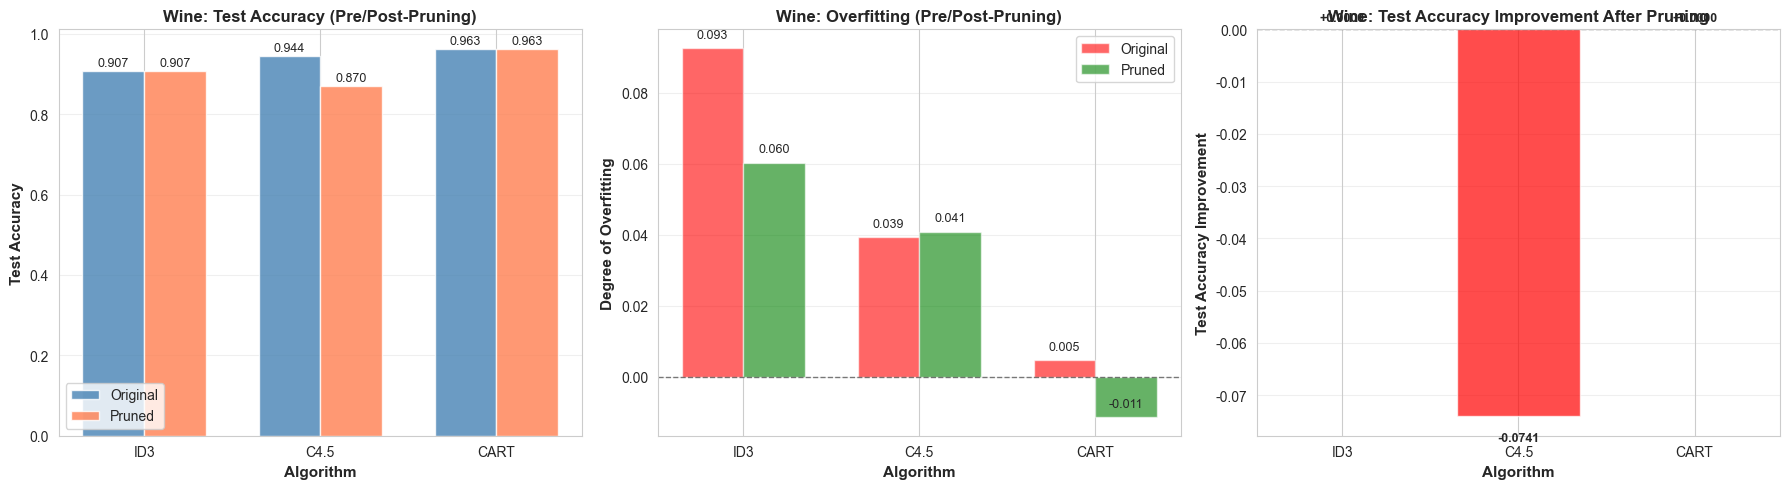

In [27]:
# 剪枝前后对比可视化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

algorithms = pruning_comparison['算法'].tolist()
x = np.arange(len(algorithms))
width = 0.35

# 1. 测试集准确率对比
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, pruning_comparison['原始-测试集准确率'], width,
                label='Original', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, pruning_comparison['剪枝-测试集准确率'], width,
                label='Pruned', color='coral', alpha=0.8)
ax1.set_xlabel('Algorithm', fontsize=11, fontweight='bold')
ax1.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('Wine: Test Accuracy (Pre/Post-Pruning)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(algorithms)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# 2. 过拟合程度对比
ax2 = axes[1]
bars3 = ax2.bar(x - width/2, pruning_comparison['原始-过拟合程度'], width,
                label='Original', color='red', alpha=0.6)
bars4 = ax2.bar(x + width/2, pruning_comparison['剪枝-过拟合程度'], width,
                label='Pruned', color='green', alpha=0.6)
ax2.set_xlabel('Algorithm', fontsize=11, fontweight='bold')
ax2.set_ylabel('Degree of Overfitting', fontsize=11, fontweight='bold')
ax2.set_title('Wine: Overfitting (Pre/Post-Pruning)', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(algorithms)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
for bar in bars3:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.002,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars4:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.002,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# 3. 改进幅度
ax3 = axes[2]
colors_improve = ['green' if val > 0 else 'red' for val in pruning_comparison['测试集准确率提升']]
bars5 = ax3.bar(x, pruning_comparison['测试集准确率提升'], width*2,
                color=colors_improve, alpha=0.7)
ax3.set_xlabel('Algorithm', fontsize=11, fontweight='bold')
ax3.set_ylabel('Test Accuracy Improvement', fontsize=11, fontweight='bold')
ax3.set_title('Wine: Test Accuracy Improvement After Pruning', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(algorithms)
ax3.grid(axis='y', alpha=0.3)
ax3.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
for bar in bars5:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + (0.001 if height >= 0 else -0.003),
             f'{height:+.4f}', ha='center', 
             va='bottom' if height >= 0 else 'top', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{pic_dir}/wine_pruning_comparison.png', dpi=300, bbox_inches='tight')
print(f"✓ Image saved: {pic_dir}/wine_pruning_comparison.png")
plt.show()


In [28]:
print("="*80)
print("实验总结")
print("="*80)

print("\n1. 算法性能排名（按测试集准确率）:")
test_ranking = all_results.nlargest(8, 'test_accuracy')[['algorithm', 'test_accuracy']]
for i, (idx, row) in enumerate(test_ranking.iterrows(), 1):
    print(f"   {i}. {row['algorithm']:20s}: {row['test_accuracy']:.6f}")

print("\n2. 泛化能力排名（按过拟合程度，越小越好）:")
overfitting_ranking = all_results.nsmallest(8, 'overfitting')[['algorithm', 'overfitting']]
for i, (idx, row) in enumerate(overfitting_ranking.iterrows(), 1):
    print(f"   {i}. {row['algorithm']:20s}: {row['overfitting']:.6f}")

print("\n3. 后剪枝效果总结:")
print(f"   - ID3: 测试集准确率 {'提升' if pruning_comparison.loc[0, '测试集准确率提升'] > 0 else '下降'} "
      f"{abs(pruning_comparison.loc[0, '测试集准确率提升']):.4f}, "
      f"过拟合减少 {pruning_comparison.loc[0, '过拟合减少']:.4f}")
print(f"   - C4.5: 测试集准确率 {'提升' if pruning_comparison.loc[1, '测试集准确率提升'] > 0 else '下降'} "
      f"{abs(pruning_comparison.loc[1, '测试集准确率提升']):.4f}, "
      f"过拟合减少 {pruning_comparison.loc[1, '过拟合减少']:.4f}")
print(f"   - CART: 测试集准确率 {'提升' if pruning_comparison.loc[2, '测试集准确率提升'] > 0 else '下降'} "
      f"{abs(pruning_comparison.loc[2, '测试集准确率提升']):.4f}, "
      f"过拟合减少 {pruning_comparison.loc[2, '过拟合减少']:.4f}")

print("\n4. 最重要的特征（前5个）:")

# 获取实际列名，兼容列名格式问题
columns = importance_df_sorted.columns
feat_col = [col for col in columns if "特征" in col][0]

# 直接使用实际列名，不做多余防护
id3_col = [col for col in columns if 'ID3' in str(col)][0]
c45_col = [col for col in columns if 'C4.5' in str(col)][0]
cart_col = [col for col in columns if 'CART' in str(col)][0]

top5_features = importance_df_sorted.head(5)
for i, (idx, row) in enumerate(top5_features.iterrows(), 1):
    id3_val = row[id3_col]
    c45_val = row[c45_col]
    cart_val = row[cart_col]
    print(f"   {i}. {row[feat_col]:20s}: ID3={id3_val:.4f}, C4.5={c45_val:.4f}, CART={cart_val:.4f}")


print("\n" + "="*80)
print("所有图片已保存到 pic/ 文件夹")
print("="*80)


实验总结

1. 算法性能排名（按测试集准确率）:
   1. CART (pruning)      : 0.962963
   2. sklearn-Gini        : 0.962963
   3. CART (raw)          : 0.962963
   4. C4.5 (raw)          : 0.944444
   5. ID3 (raw)           : 0.907407
   6. ID3 (pruning)       : 0.907407
   7. sklearn-Entropy     : 0.907407
   8. C4.5 (pruning)      : 0.870370

2. 泛化能力排名（按过拟合程度，越小越好）:
   1. CART (pruning)      : -0.011350
   2. CART (raw)          : 0.004779
   3. sklearn-Gini        : 0.037037
   4. C4.5 (raw)          : 0.039427
   5. C4.5 (pruning)      : 0.040920
   6. ID3 (pruning)       : 0.060335
   7. ID3 (raw)           : 0.092593
   8. sklearn-Entropy     : 0.092593

3. 后剪枝效果总结:
   - ID3: 测试集准确率 下降 0.0000, 过拟合减少 0.0323
   - C4.5: 测试集准确率 下降 0.0741, 过拟合减少 -0.0015
   - CART: 测试集准确率 下降 0.0000, 过拟合减少 0.0161

4. 最重要的特征（前5个）:
   1. flavanoids          : ID3=0.4091, C4.5=0.3869, CART=0.4354
   2. alcohol             : ID3=0.3420, C4.5=0.2818, CART=0.0188
   3. hue                 : ID3=0.1485, C4.5=0.0000, CART=0.0000
   4.